# Run this first !
Ensures correct libraries and imports data

In [1]:
# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

utt = loading.load(DATA, "all_utterances.csv", "2026-09-30")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-30")
met = loading.load(DATA, "all_metrics.csv", "2026-09-30")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23', '2026-09-30']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  2570 rows
loaded all_sentences.csv  19092 rows
loaded all_metrics.csv  1021 rows
(2570, 11) (19092, 12) (1021, 6)


# Sentence pre-processing (stop words, speaker names and greetings etc)
This is just a starting point as there are several oddities - for example greeting words mean the Bert Emotion skews towards "Joy" and some stopwords such as "us" seems to be treated as a plural of "u" - hence needs removing. Also need to work out how to differentiate between "credit" and "Credit Suisse" as both are valid but cannot be treated as the same

### Import ntlk

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Speaker Names
Need to remove these from the sentences

In [3]:
# Create a list using "speaker_name" column from the dataframe
speaker_names = data["speaker_name"].tolist()
# Reduce list to contain only unique speaker names
speaker_names = list(set(speaker_names))
# Split first and last names of the speakers
speaker_names_split = [name.split() for name in speaker_names]
# remove capital letters from speaker names
speaker_names_split = [[name.lower() for name in sublist] for sublist in speaker_names_split]
speaker_names_split[:10]

[['ken', 'usdin'],
 ['sarah', 'youngwood'],
 ['saul', 'martinez'],
 ['jeremy', 'sigee'],
 ['ebrahim', 'h.', 'poonawala'],
 ['piers', 'brown'],
 ['kian', 'abouhossein'],
 ['alastair', 'ryan'],
 ['flora', 'bocahut'],
 ['ryan', 'kenny']]

### Pre-processing Function

In [4]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove words that are not informative for topic modeling
    stop_words.update(['also', 'quarter', 'year', 'u', 'think', 'thats', 'question'])

    # Remove speaker names from the text
    speaker_names_flat = [name for sublist in speaker_names_split for name in sublist]
    

    greeting_words = {
    "hello", "hi", "dear", "greetings",
    "thank", "thanks", "good", "morning",
    "afternoon", "evening",
    "ladies", "gentlemen", "sir", "madam",
    "yeah", "welcome",
    "mr", "mrs", "ms"
}

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word not in stop_words and word.isalpha() and word not in greeting_words and word not in speaker_names_flat # Ensure only alphabetic words are kept and remove greeting words and speaker names
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [5]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head(10))

                                            sentence  \
0                Good morning, ladies and gentlemen.   
1  Welcome to JPMorgan Chase's First Quarter 2022...   
2                       This call is being recorded.   
3  Your line will be muted for the duration of th...   
4           We will now go live to the presentation.   
5                                   Please stand by.   
6  At this time, I would like to turn the call ov...   
7                       Mr. Barnum, please be ahead.   
8                                  Thanks, operator.   
9                            Good morning, everyone.   

                                        cleaned_text  
0                                                 []  
1           [jpmorgan, chase, first, earnings, call]  
2                                   [call, recorded]  
3                      [line, muted, duration, call]  
4                           [go, live, presentation]  
5                                    [please, stand] 

In [6]:
data.shape



(19092, 13)

# Choose Bank
Amend the commented section to include the bank of choice. Default is set as UBS

In [ ]:
# Create dataframe with bank = '***' (replace with bank of choice)
data = data[data['bank'] == 'JPM'].copy()
print(data.shape)
data.head(2)

(9905, 13)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,1,"Good morning, ladies and gentlemen.",[]
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...,"[jpmorgan, chase, first, earnings, call]"


## Split by Section to check speakers
Are the same speakers who give the presentation, the same as those who are involved in the Q&A. If so then their language can be directly compared in both

In [8]:
# List all speaker names that are speaker_role = management and section = 'Q&A'
management_qa_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'qa')]['speaker_name'].unique()
print(management_qa_speakers)

['Jeremy Barnum' 'Jamie Dimon']


In [9]:
# List all speaker names that are speaker_role = management and section = "prepared"
management_prepared_speakers = data[(data['speaker_role'] == 'management') & (data['section'] == 'prepared')]['speaker_name'].unique()
print(management_prepared_speakers)

['Jeremy Barnum' 'Jamie Dimon']


All of the speakers listed as Management in the Q&A session match those in the presentation section and therefore their responses during a scripted presentation vs an open Q&A session can be investigated.

# Bert Emotion: All sections

Truncation = True means only 512 tokens (350 -400 words) are kept. Anything longer is ignored. Also output contains top_k = None so that the scores for all the emotions are retained to allow comparison later on

## Fix colours for emotions

In [10]:
# Fix colours of bars to emotion categories to be used in sns and matplotlib
emotion_palette = {
    'joy': 'darkorange',
    'anger': 'red',
    'sadness': 'dodgerblue',
    'fear': 'purple',
    'surprise': 'green',
    'disgust': 'brown',
    'love': 'deeppink'
}

## Build pipeline

In [11]:
# Conduct Bert Emotion analysis on cleaned sentences from presentation section (UBS)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6775.17it/s]


## Run the model

In [12]:
# Run the model and keep all emotion scores
basic_emotion = emotion_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
emotion_rows = []
for result in basic_emotion:
    if isinstance(result, list):
        emotion_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        emotion_rows.append({result["label"]: result["score"]})
    else:
        emotion_rows.append({})

# Add the top emotion and score to the dataframe
data["main_emotion"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in emotion_rows
]
data["main_emotion_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in emotion_rows
]

# Add all emotion columns as separate numeric columns
for emotion in ["anger", "joy", "fear", "sadness", "love", "surprise"]:
    data[emotion] = [row.get(emotion, 0.0) for row in emotion_rows]

In [13]:
data.head(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,...,"Good morning, ladies and gentlemen.",[],anger,0.291548,0.291548,0.236256,0.224192,0.070036,0.112292,0.065676
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,Welcome to JPMorgan Chase's First Quarter 2022...,"[jpmorgan, chase, first, earnings, call]",joy,0.593408,0.306026,0.593408,0.019267,0.067056,0.005982,0.008261


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

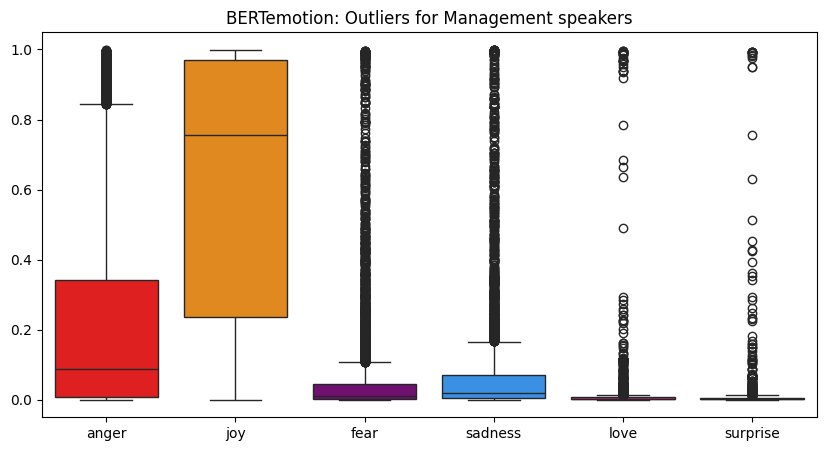

In [14]:
# Look for outliers in emotions of ubs_data where speaker_role = "management"
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize outliers of last 6 columns (emotions) using boxplots
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -6:], palette=emotion_palette)
plt.title("BERTemotion: Outliers for Management speakers")
plt.show()

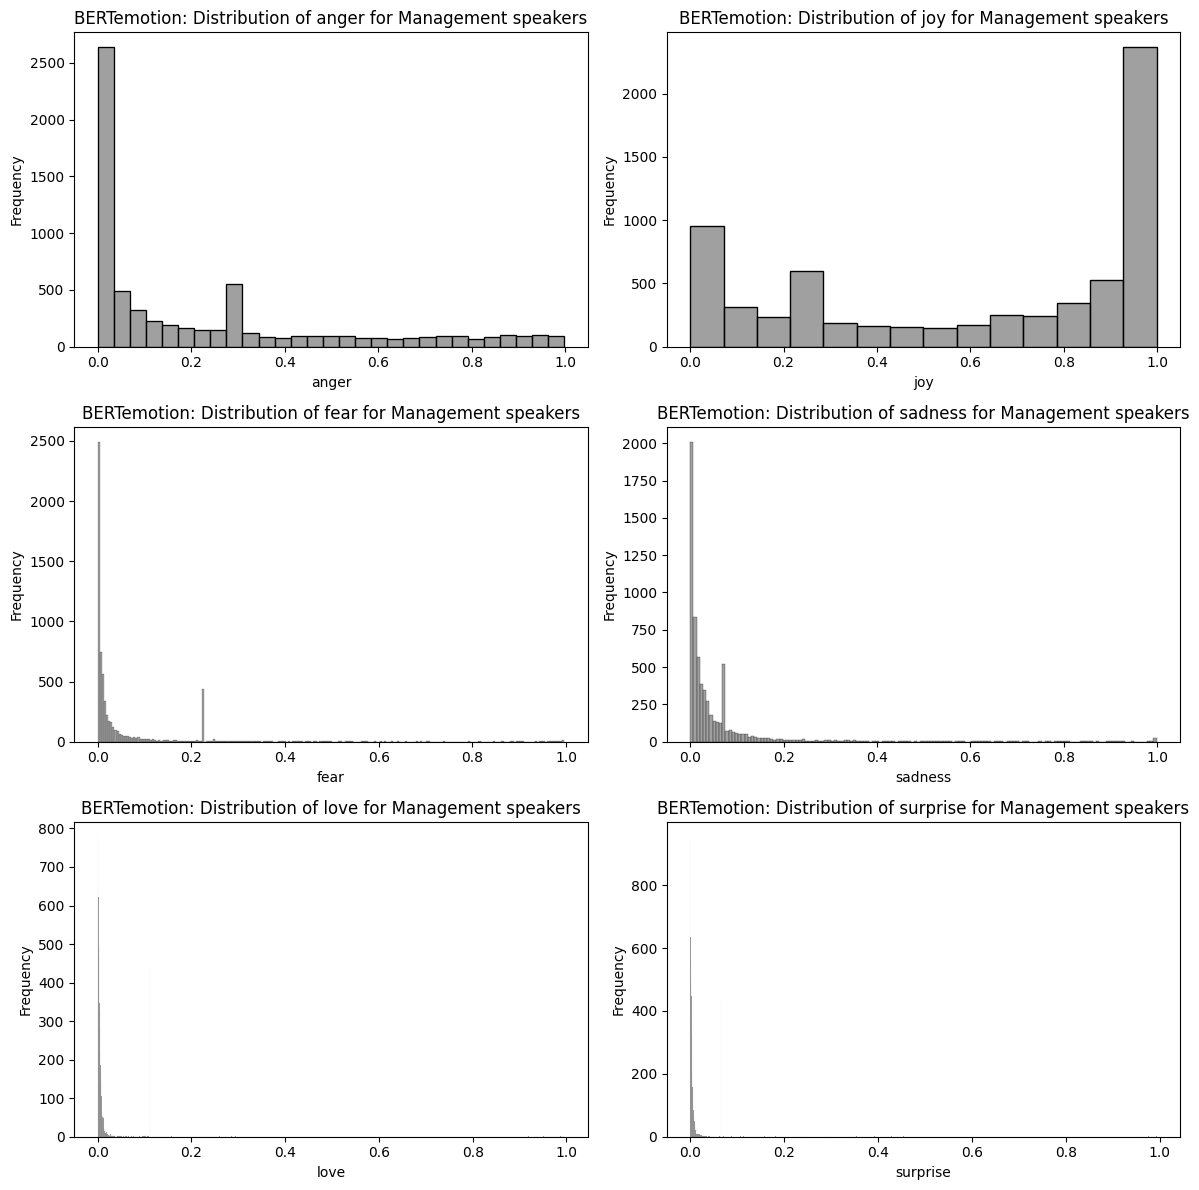

In [15]:
# Create a 3x2 grid of histograms for each emotion column
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
emotion_columns = management_data.columns[-6:]
for i, emotion in enumerate(emotion_columns):
    ax = axes[i // 2, i % 2]
    sns.histplot(data=management_data, x=emotion, ax=ax, color='grey')
    ax.set_xlabel(emotion)
    ax.set_ylabel('Frequency')
    ax.set_title(f"BERTemotion: Distribution of {emotion} for Management speakers")
plt.tight_layout()
plt.show()

## Calculate quarterly statistics (Management not Analyst)

In [16]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS)
emotion_stats = data.groupby(["quarter", "main_emotion", "speaker_role","section"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
emotion_stats = emotion_stats[emotion_stats['speaker_role'] != 'analyst']
emotion_stats.head(10)   

,quarter,main_emotion,speaker_role,section,median_score,std_score
1,2022-Q1,anger,management,prepared,0.590989,0.182596
2,2022-Q1,anger,management,qa,0.642977,0.244223
3,2022-Q1,anger,operator,prepared,0.536294,0.177282
4,2022-Q1,anger,operator,qa,0.597866,0.226953
6,2022-Q1,fear,management,prepared,0.995227,0.000000
7,2022-Q1,fear,management,qa,0.737858,0.203389
8,2022-Q1,fear,operator,qa,0.907927,0.000000
10,2022-Q1,joy,management,prepared,0.931397,0.172222
11,2022-Q1,joy,management,qa,0.941694,0.166913
12,2022-Q1,joy,operator,prepared,0.943623,0.185683


In [17]:
# Calculate max and mean values for std_score
emotion_std_max = emotion_stats.groupby('main_emotion')['std_score'].max()
emotion_std_mean = emotion_stats.groupby('main_emotion')['std_score'].mean()
print("Max std_score per emotion:")
print(emotion_std_max)
print("\nMean std_score per emotion:")
print(emotion_std_mean)

Max std_score per emotion:
main_emotion
anger       0.273402
fear        0.329361
joy         0.221110
love        0.196476
sadness     0.282050
surprise    0.430872
Name: std_score, dtype: float64

Mean std_score per emotion:
main_emotion
anger       0.199983
fear        0.132821
joy         0.150815
love        0.027219
sadness     0.177975
surprise    0.079152
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections for all emotions

In [18]:
# Calculate differences between prepared and QA emotion scores for UBS management if NaN use zero
diff_emotion_stats = emotion_stats.pivot_table(index=['quarter', 'main_emotion'], columns='section', values='median_score').reset_index()
diff_emotion_stats = diff_emotion_stats.fillna(0)
diff_emotion_stats['diff'] = diff_emotion_stats['qa'] - diff_emotion_stats['prepared']

In [19]:
# Find max standard deviation from all emotions from emotion_std_max values
all_emotion_std_max = emotion_std_max.max()
print("Value for error bars: ", all_emotion_std_max)

Value for error bars:  0.43087222672841824


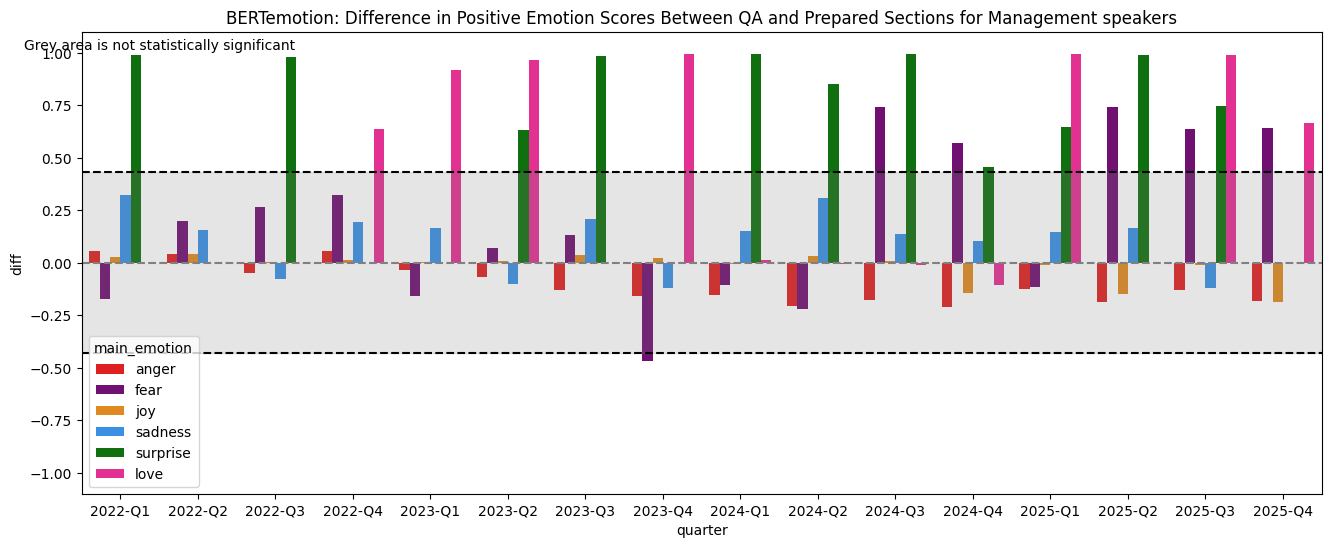

In [20]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
plt.title("Difference in Emotion Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_emotion_std_max, linestyle='--', color='black')
plt.axhline(-all_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_emotion_std_max,
    all_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=0.5, 
    y=1.0, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure
plt.savefig("difference_in_emotion_scores_management.png")

## Positive Emotions
In order to build a comparison with FinBert, the BertEmotion categories will be split into:  
* POSITIVE = Love & Joy

### Median positive emotions over time

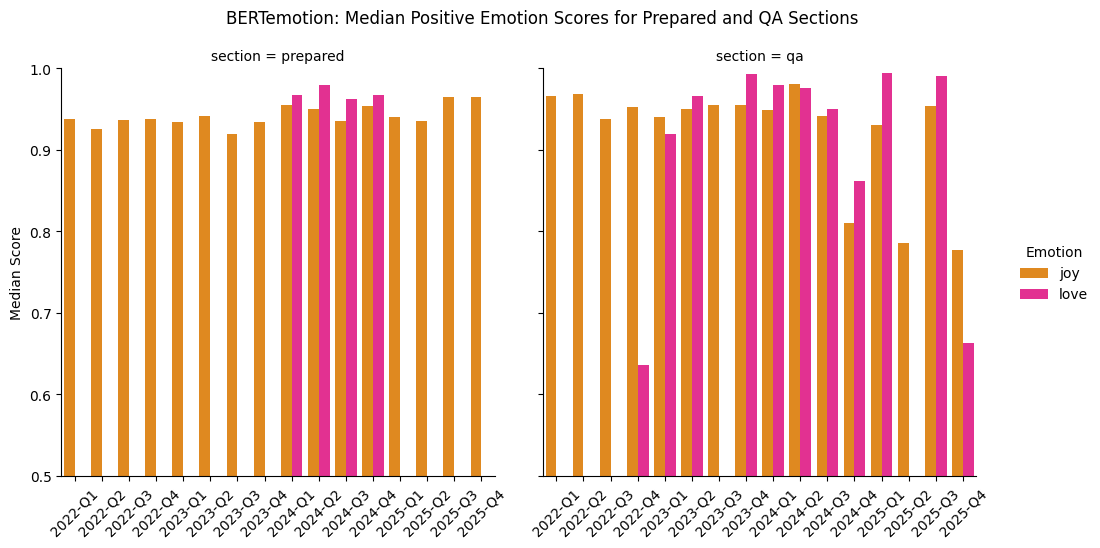

In [21]:
# Plot Positive Emotion Scores for prepared and QA sections using "Joy" and "Love" emotions

positive_emotions = ["joy", "love"]
emotion_positive = emotion_stats[emotion_stats['main_emotion'].isin(positive_emotions)].copy()

g = sns.catplot(
    kind="bar",
    data=emotion_positive,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_emotion",
    palette=emotion_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Remove x title
g.set_xlabels("")
g.legend.set_title("Emotion")
g.fig.suptitle("BERTemotion: Median Positive Emotion Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in positive emotions over time


Find worst case scenario using maximum standard deviation from "joy" and "love"

In [22]:
# Find max standard deviation for "joy" and "love" emotions from emotion_std_max values
positive_emotion_std_max = emotion_std_max[emotion_std_max.index.isin(['joy', 'love'])].max()
print("Value for error bars: ", positive_emotion_std_max)

Value for error bars:  0.22111026677416937


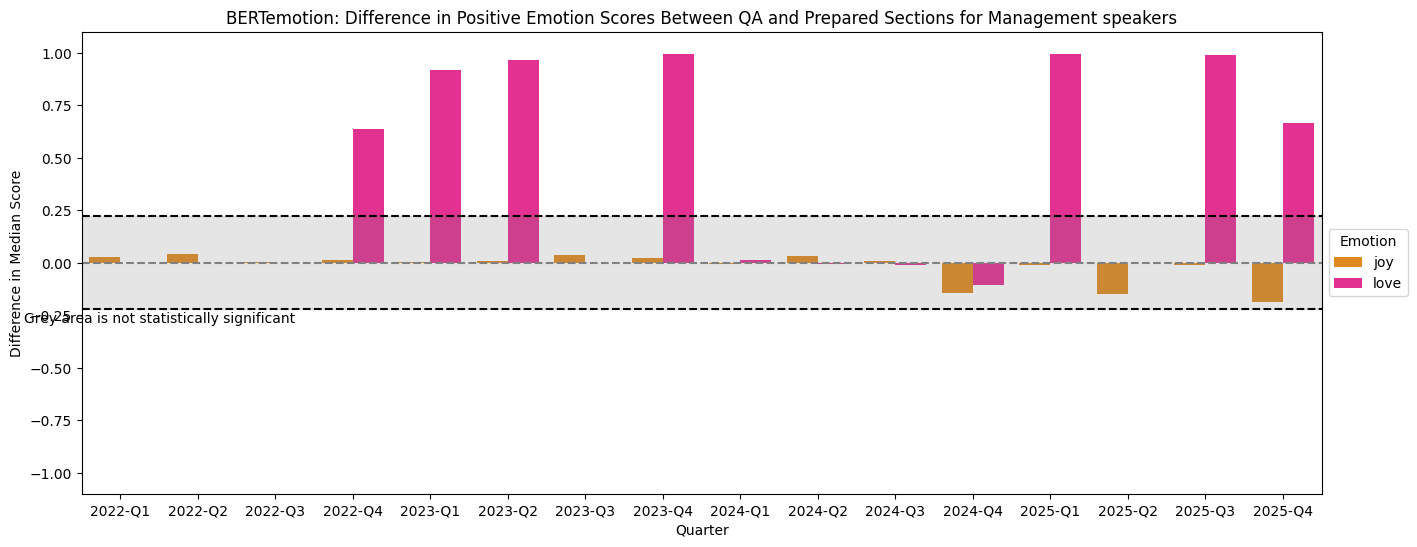

In [23]:
# Plot results as bar chart for "joy" and "love" emotions only
diff_positive_emotion_stats = diff_emotion_stats[diff_emotion_stats['main_emotion'].isin(['joy', 'love'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_positive_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
# fix y axis as -1.1 to +1.1
plt.ylim(-1.1, 1.1)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(positive_emotion_std_max, linestyle='--', color='black')
plt.axhline(-positive_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -positive_emotion_std_max,
    positive_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Positive Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=0.5, 
    y=-0.3, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("diff_positive_emotion_scores.png")
plt.show()

## Negative Emotions
In order to build a comparison with FinBert, the BertEmotion categories will be split into:  
* NEGATIVE = Anger, Fear and Sadness

### Median negative emotions over time

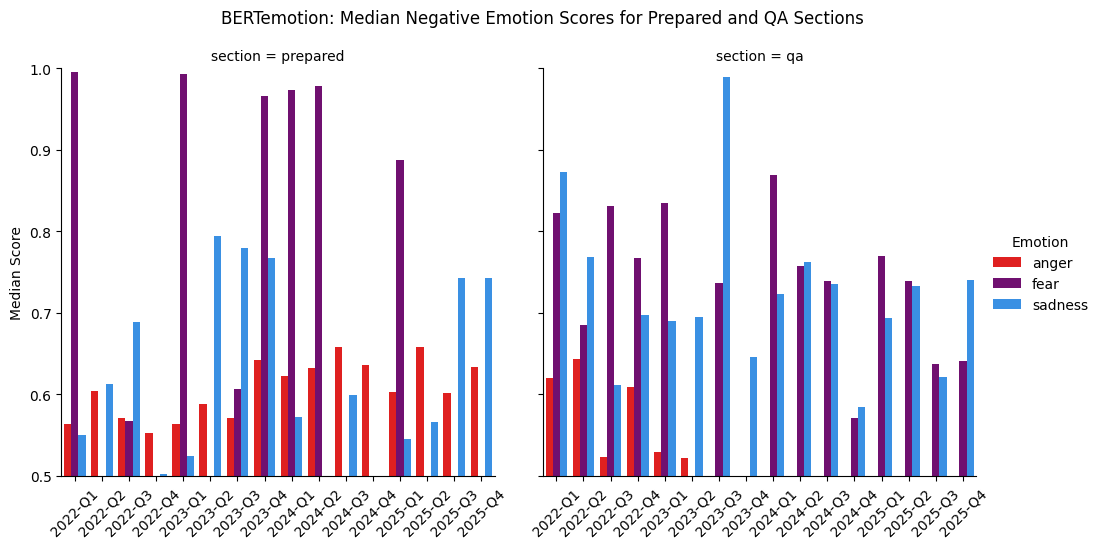

In [24]:
# Plot Negative Emotion Scores for prepared and QA sections using "Anger", "Sadness", and "Fear" emotions

negative_emotions = ["anger", "sadness", "fear"]
emotion_negative = emotion_stats[emotion_stats['main_emotion'].isin(negative_emotions)].copy()

g = sns.catplot(
    kind="bar",
    data=emotion_negative,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_emotion",
    palette=emotion_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Remove x title
g.set_xlabels("")
g.legend.set_title("Emotion")
g.fig.suptitle("BERTemotion: Median Negative Emotion Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in negative emotions over time

Find worst case scenario using maximum standard deviation from "anger", "fear" and "sadness"

In [25]:
# Find max standard deviation for "anger", "fear", "sadness" emotions from emotion_std_max values
negative_emotion_std_max = emotion_std_max[emotion_std_max.index.isin(['anger', 'fear', 'sadness'])].max()
print("Value for error bars: ", negative_emotion_std_max)

Value for error bars:  0.3293611846626599


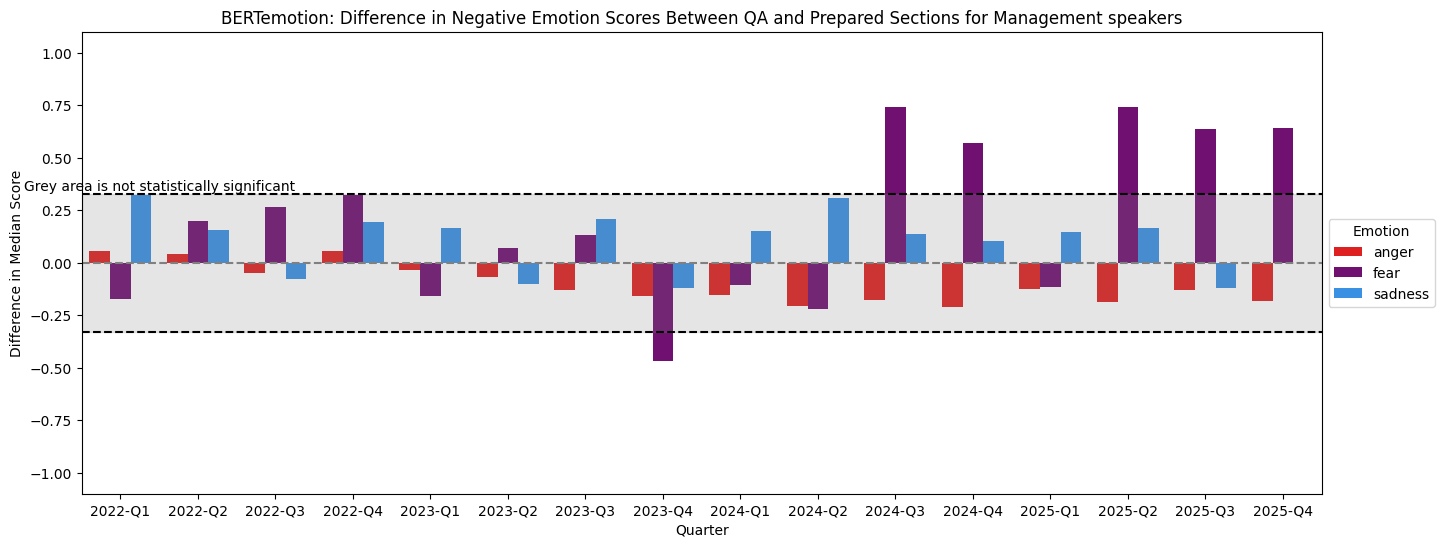

In [26]:
# Plot results as bar chart for "anger", "fear" and "sadness" emotions only
diff_negative_emotion_stats = diff_emotion_stats[diff_emotion_stats['main_emotion'].isin(['anger', 'fear', 'sadness'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_negative_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
# fix y axis as -1.1 to +1.1
plt.ylim(-1.1, 1.1)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of negative emotion standard deviation
plt.axhline(negative_emotion_std_max, linestyle='--', color='black')
plt.axhline(-negative_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -negative_emotion_std_max,
    negative_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Negative Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=0.5, 
    y=negative_emotion_std_max, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("diff_negative_emotion_scores.png")
plt.show()

## Other Emotions ("Surprise")
This does not really correlate with the FinBERT classification of "Neutral"

### Median "Suprise" emotion over time

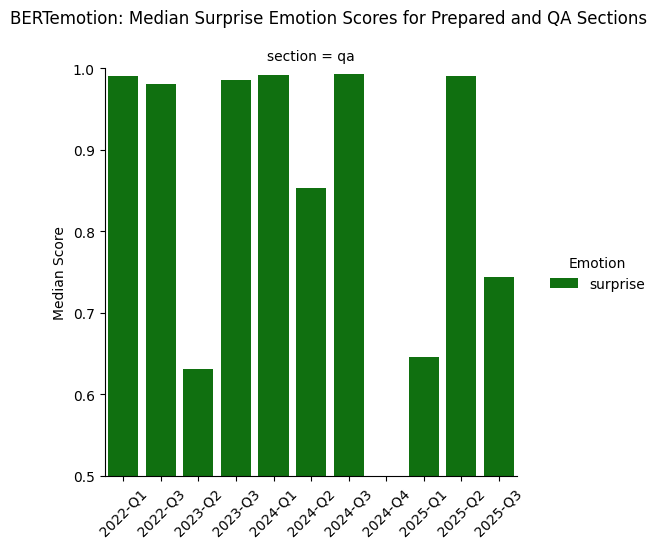

In [27]:
# Plot Surprise Emotion Scores for prepared and QA sections

surprise_emotions = ["surprise"]
emotion_surprise = emotion_stats[emotion_stats['main_emotion'].isin(surprise_emotions)].copy()

g = sns.catplot(
    kind="bar",
    data=emotion_surprise,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_emotion",
    palette=emotion_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Remove x title
g.set_xlabels("")
g.legend.set_title("Emotion")
g.fig.suptitle("BERTemotion: Median Surprise Emotion Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in surprise emotion over time

Find worst case scenario using maximum standard deviation from "surprise" - although if only one value then this will be zero

In [28]:
# Find max standard deviation for "surprise" emotions from emotion_std_max values
surprise_emotion_std_max = emotion_std_max[emotion_std_max.index.isin(['surprise'])].max()
print("Value for error bars: ", surprise_emotion_std_max)

Value for error bars:  0.43087222672841824


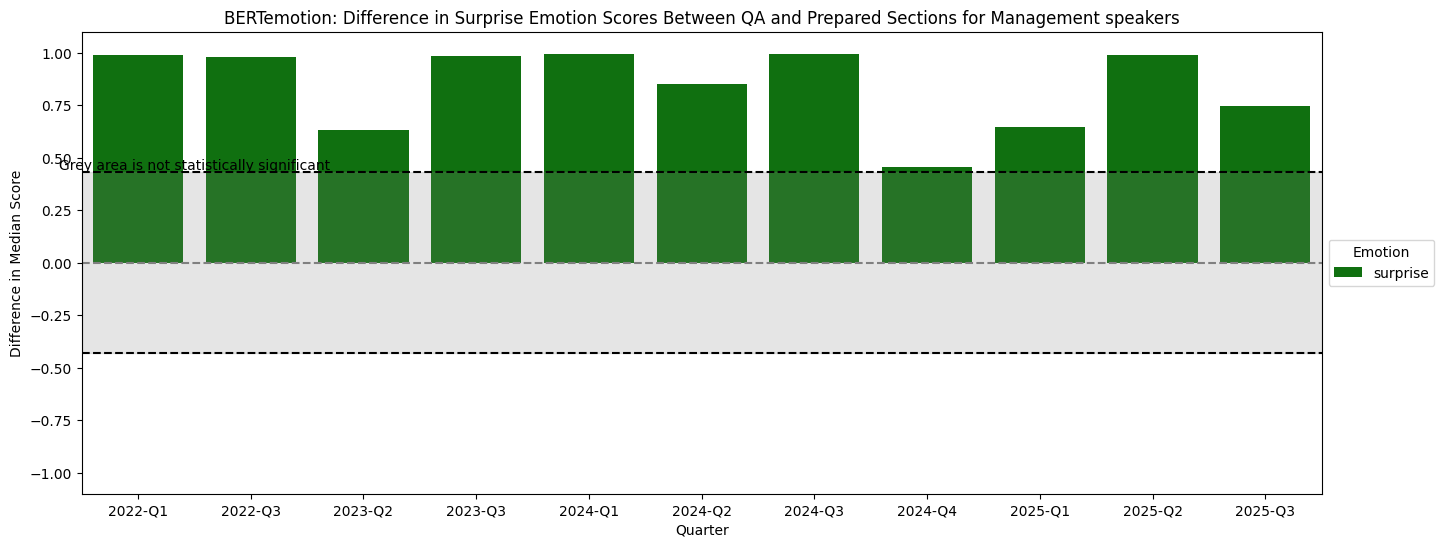

In [29]:
# Plot results as bar chart for "surprise" only
diff_negative_emotion_stats = diff_emotion_stats[diff_emotion_stats['main_emotion'].isin(['surprise'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_negative_emotion_stats, x="quarter", y="diff", hue="main_emotion", palette=emotion_palette)
# fix y axis as -1.1 to +1.1
plt.ylim(-1.1, 1.1)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of surprise emotion standard deviation
plt.axhline(surprise_emotion_std_max, linestyle='--', color='black')
plt.axhline(-surprise_emotion_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -surprise_emotion_std_max,
    surprise_emotion_std_max,
    color='grey',
    alpha=0.2
)

plt.title("BERTemotion: Difference in Surprise Emotion Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of surprise emotion scores"
# Only show if value is > 0
if surprise_emotion_std_max > 0:
    plt.text(
        x=0.5, 
        y=surprise_emotion_std_max, 
        s="Grey area is not statistically significant", 
        color='black', 
        ha='center', 
        va='bottom'
    )
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("diff_surprise_emotion_scores.png")
plt.show()

In [30]:
# Display sentences classified as "surprise" for whole dataset, group by speaker_role
print(data[data['main_emotion'] == 'surprise'].groupby('speaker_role')['sentence'].apply(list))






speaker_role
analyst       [And just curious on how you thought about tha...
management    [...you'd be shocked., And you're always going...
Name: sentence, dtype: object


Apparently the word "Regardless" can trigger a classification of "surprise" in the model. This "catch all" emotion could therefore be comparable to FinBERT = neutral.

Note:
Domain mismatch — bhadresh-savani/bert-base-uncased-emotion was fine-tuned on general/social-media text, not financial-earnings-call language. Financial hedging language ("regardless of," "whether... or...") has no equivalent in its training distribution, so predictions on this domain are noisy and often wrong.

# FinBERT Model

## Fix colours for sentiments

In [31]:
# Fix colours of bars to sentiment categories to be used in sns and matplotlib
sentiment_palette = {
    'positive': 'darkorange',
    'neutral': 'grey',
    'negative': 'dodgerblue',
}

## Build pipeline

In [32]:
# Conduct sentiment analysis using FinBERT on UBS-related financial texts
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

# Load FinBERT model and tokenizer
model_name = "prosusai/finbert"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Create sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

documents = (
    data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 69410.10it/s]


## Run the model

In [33]:
# Run the model and keep all sentiment scores
basic_sentiment = sentiment_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
sentiment_rows = []
for result in basic_sentiment:
    if isinstance(result, list):
        sentiment_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        sentiment_rows.append({result["label"]: result["score"]})
    else:
        sentiment_rows.append({})

# Add the top sentiment and score to the dataframe
data["main_sentiment"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in sentiment_rows
]
data["main_sentiment_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in sentiment_rows
]

# Add all sentiment columns as separate numeric columns
for sentiment in ["positive", "negative", "neutral"]:
    data[sentiment] = [row.get(sentiment, 0.0) for row in sentiment_rows]

In [34]:
data.head(10)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,joy,fear,sadness,love,surprise,main_sentiment,main_sentiment_score,positive,negative,neutral
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,...,0.236256,0.224192,0.070036,0.112292,0.065676,neutral,0.424185,0.359163,0.216652,0.424185
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,0.593408,0.019267,0.067056,0.005982,0.008261,neutral,0.900009,0.028033,0.071958,0.900009
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,...,0.203670,0.227531,0.013340,0.009466,0.009699,neutral,0.907021,0.037827,0.055152,0.907021
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,...,0.002711,0.322691,0.027531,0.003867,0.007104,neutral,0.872745,0.027561,0.099694,0.872745
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,...,0.982614,0.004017,0.003495,0.001337,0.001804,neutral,0.932259,0.033197,0.034545,0.932259
5,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38073,...,0.943623,0.010608,0.022998,0.008748,0.001015,neutral,0.900591,0.058991,0.040418,0.900591
6,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38074,...,0.673268,0.012704,0.044274,0.003811,0.003194,neutral,0.942388,0.027817,0.029794,0.942388
7,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38075,...,0.975741,0.002637,0.003689,0.008436,0.000929,neutral,0.883613,0.067334,0.049052,0.883613
8,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38076,...,0.236256,0.224192,0.070036,0.112292,0.065676,neutral,0.424185,0.359163,0.216652,0.424185
9,JPM,2022-Q1,earnings,2022-04-13,2,prepared,management,Jeremy Barnum,NaN,38077,...,0.182400,0.017210,0.057599,0.007096,0.006089,neutral,0.875718,0.078929,0.045353,0.875718


## Check outliers
Use boxplots to check shape of data for outliers. Suspect data is noisy hence using the median values rather than the mean if the data is skewed.

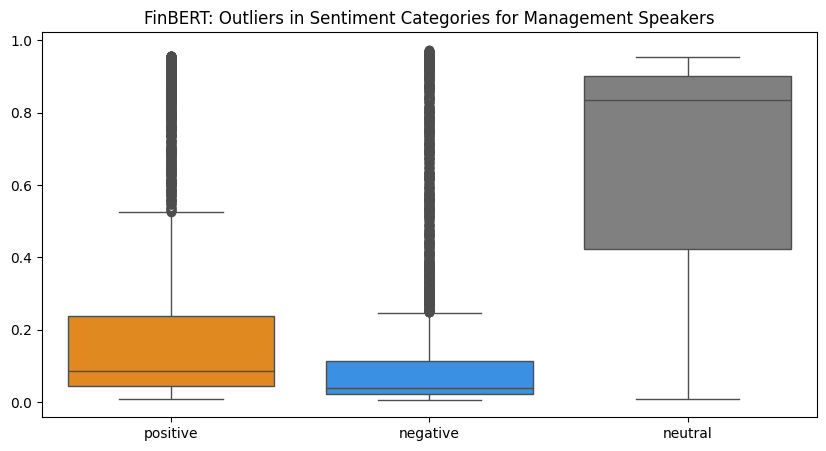

In [35]:
# Look for outliers in sentiments categories of data where speaker_role = "management"
# Display as vertical boxes on the same plot
management_data = data[data['speaker_role'] == 'management']
plt.figure(figsize=(10, 5))
sns.boxplot(data=management_data.iloc[:, -3:], palette=sentiment_palette)
plt.title("FinBERT: Outliers in Sentiment Categories for Management Speakers")
plt.show()

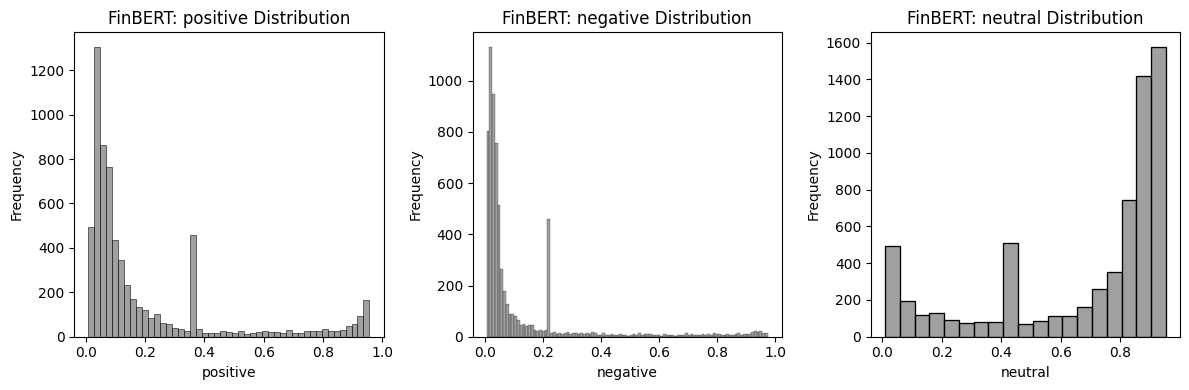

In [36]:
# Create a 1x3 grid of histograms for each sentiment category
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
emotion_columns = management_data.columns[-3:]
for i, emotion in enumerate(emotion_columns):
    ax = axes[i]
    sns.histplot(data=management_data, x=emotion, ax=ax, color='grey')
    ax.set_xlabel(emotion)
    ax.set_ylabel('Frequency')
    ax.set_title(f"FinBERT: {emotion} Distribution")
plt.tight_layout()
plt.show()

The scores are highly skewed towards either end of the distribution - being either "very positive" or "very negative" but with little in the middle

In [37]:
# Calculate % of sentences in each sentiment category

management_data['positive'].sum() / len(management_data) * 100
management_data['negative'].sum() / len(management_data) * 100
management_data['neutral'].sum() / len(management_data) * 100

# display the percentage to 2 significant figures

print("Percentage of Positive sentences (Management):", round(management_data['positive'].sum() / len(management_data) * 100, 2),"%")
print("Percentage of Negative sentences (Management):", round(management_data['negative'].sum() / len(management_data) * 100, 2),"%")
print("Percentage of Neutral sentences (Management):", round(management_data['neutral'].sum() / len(management_data) * 100, 2),"%")

Percentage of Positive sentences (Management): 20.04 %
Percentage of Negative sentences (Management): 12.36 %
Percentage of Neutral sentences (Management): 67.59 %


Very little negative sentiment from the Management prepared presentation or the Q&A session

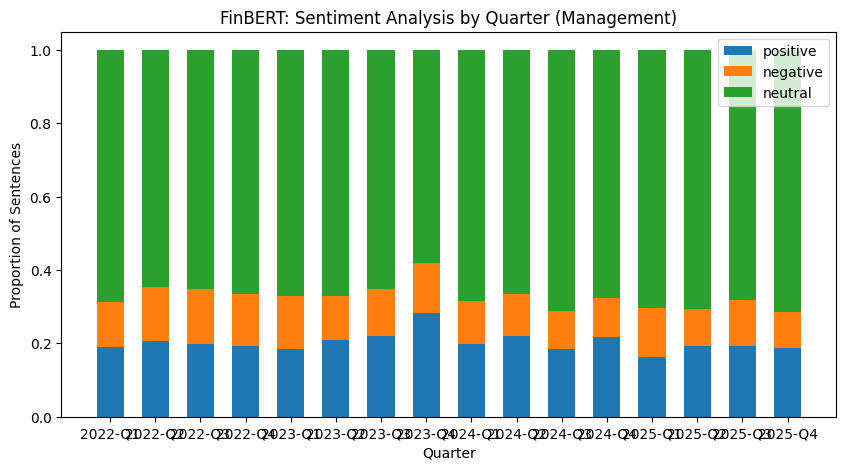

In [38]:
# Plot sentiments as a stacked bar chart for each quarter

fig, ax = plt.subplots(figsize=(10, 5))

quarters = management_data['quarter'].unique()
positive = management_data.groupby('quarter')['positive'].sum()
negative = management_data.groupby('quarter')['negative'].sum()
neutral = management_data.groupby('quarter')['neutral'].sum()

# Normalise the data for stacked bar chart
total = positive + negative + neutral
positive = positive / total
negative = negative / total
neutral = neutral / total
bar_width = 0.6
index = np.arange(len(quarters))

ax.bar(index, positive, bar_width, label='positive')
ax.bar(index, negative, bar_width, bottom=positive, label='negative')
ax.bar(index, neutral, bar_width, bottom=positive+negative, label='neutral')

ax.set_xlabel('Quarter')
ax.set_ylabel('Proportion of Sentences')
ax.set_title('FinBERT: Sentiment Analysis by Quarter (Management)')
ax.set_xticks(index)
ax.set_xticklabels(quarters)
ax.legend()
plt.show()

## Calculate quarterly statistics (Management not Analyst)

In [39]:
# FinBERT does not create an overall score so need to add the max value and label to end to end of data column
data['main_sentiment'] = data[['positive', 'negative', 'neutral']].idxmax(axis=1)   
data['main_sentiment_score'] = data[['positive', 'negative', 'neutral']].max(axis=1)
data.head(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,joy,fear,sadness,love,surprise,main_sentiment,main_sentiment_score,positive,negative,neutral
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,...,0.236256,0.224192,0.070036,0.112292,0.065676,neutral,0.424185,0.359163,0.216652,0.424185
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,...,0.593408,0.019267,0.067056,0.005982,0.008261,neutral,0.900009,0.028033,0.071958,0.900009


In [40]:
# Create dataframe to calculate median and standard deviation of every sentiment every quarter (UBS)
sentiment_stats = data.groupby(["quarter", "main_sentiment", "speaker_role","section"]).agg(
    median_score=("main_sentiment_score", "median"),
    std_score=("main_sentiment_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()

# Drop rows where speaker_role = analyst
sentiment_stats = sentiment_stats[sentiment_stats['speaker_role'] != 'analyst']
sentiment_stats.head(10)   

,quarter,main_sentiment,speaker_role,section,median_score,std_score
1,2022-Q1,negative,management,prepared,0.834005,0.161662
2,2022-Q1,negative,management,qa,0.634099,0.183717
4,2022-Q1,neutral,management,prepared,0.864247,0.157736
5,2022-Q1,neutral,management,qa,0.871149,0.156824
6,2022-Q1,neutral,operator,prepared,0.900300,0.171717
7,2022-Q1,neutral,operator,qa,0.911907,0.033569
9,2022-Q1,positive,management,prepared,0.910376,0.148411
10,2022-Q1,positive,management,qa,0.761528,0.166011
12,2022-Q2,negative,management,prepared,0.810291,0.121463
13,2022-Q2,negative,management,qa,0.778251,0.170268


In [41]:
# Calculate max and mean values for std_score for sentiments
sentiment_std_max = sentiment_stats.groupby('main_sentiment')['std_score'].max()
sentiment_std_mean = sentiment_stats.groupby('main_sentiment')['std_score'].mean()
print("Max std_score per sentiment:")
print(sentiment_std_max)
print("\nMean std_score per sentiment:")
print(sentiment_std_mean)

Max std_score per sentiment:
main_sentiment
negative    0.248175
neutral     0.245380
positive    0.192595
Name: std_score, dtype: float64

Mean std_score per sentiment:
main_sentiment
negative    0.159300
neutral     0.150138
positive    0.145165
Name: std_score, dtype: float64


## Differences between Prepared and Q&A sections

In [42]:
# Calculate differences between prepared and QA sentiment scores for management if NaN use zero
diff_sentiment_stats = sentiment_stats.pivot_table(index=['quarter', 'main_sentiment'], columns='section', values='median_score').reset_index()
diff_sentiment_stats = diff_sentiment_stats.fillna(0)
diff_sentiment_stats['diff'] = diff_sentiment_stats['qa'] - diff_sentiment_stats['prepared']

In [43]:
diff_sentiment_stats.head(10)

section,quarter,main_sentiment,prepared,qa,diff
0,2022-Q1,negative,0.834005,0.634099,-0.199906
1,2022-Q1,neutral,0.882273,0.891528,0.009255
2,2022-Q1,positive,0.910376,0.761528,-0.148848
3,2022-Q2,negative,0.810291,0.778251,-0.032040
4,2022-Q2,neutral,0.895136,0.883879,-0.011257
5,2022-Q2,positive,0.899801,0.746861,-0.152940
6,2022-Q3,negative,0.842699,0.721862,-0.120837
7,2022-Q3,neutral,0.888576,0.882574,-0.006002
8,2022-Q3,positive,0.868415,0.746667,-0.121748
9,2022-Q4,negative,0.894999,0.734601,-0.160398


In [44]:
# Find max standard deviation from all emotions from sentiment_std_max values
all_sentiment_std_max = sentiment_std_max.max()
print("Value for error bars: ", all_sentiment_std_max)

Value for error bars:  0.24817465880032338


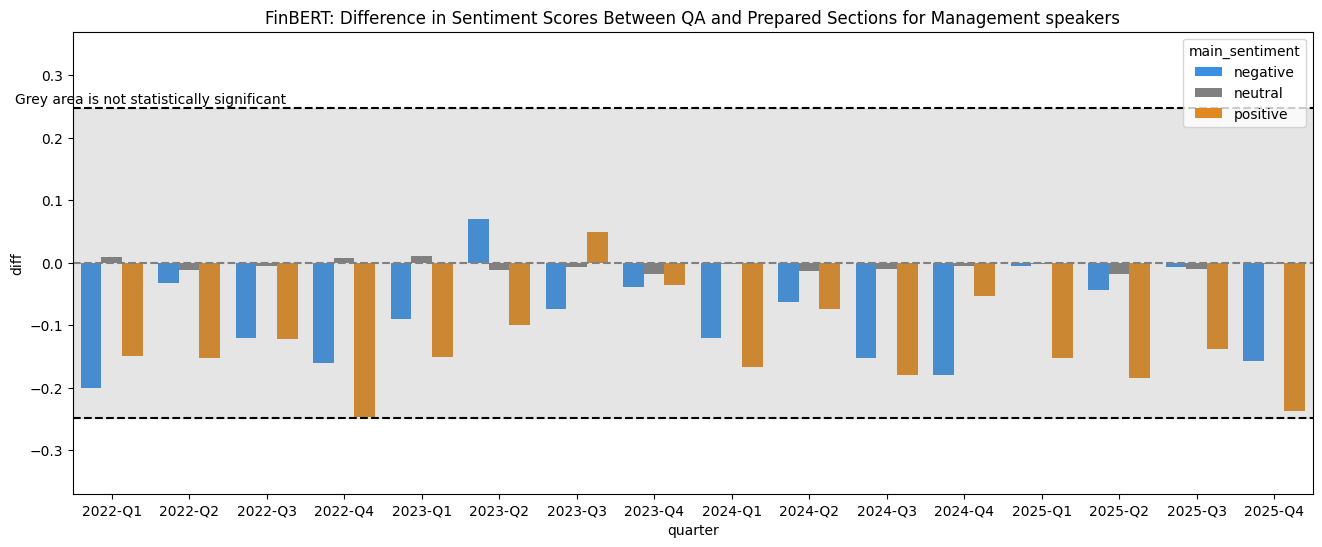

In [45]:
# Plot results as bar chart
plt.figure(figsize=(16, 6))
# fix y axis from 1.1 to -1.1
#plt.ylim(-1.1, 1.1)
sns.barplot(data=diff_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)

# Median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)

plt.title("Difference in Sentiment Scores Between QA and Prepared Sections - Management (Excluding Analysts)")
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive emotion standard deviation
plt.axhline(all_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-all_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -all_sentiment_std_max,
    all_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive emotion scores"
plt.text(
    x=0.5, 
    y=0.25, 
    s="Grey area is not statistically significant", 
    color='black', 
    ha='center', 
    va='bottom'
)

# Save figure
plt.savefig("difference_in_sentiment_scores_management.png")

/var/folders/c9/gw94qsq971z4r0zg7fh_c7240000gn/T/ipykernel_52950/3554918685.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_diff_sentiment_stats, x="main_sentiment", y="diff", palette=sentiment_palette)


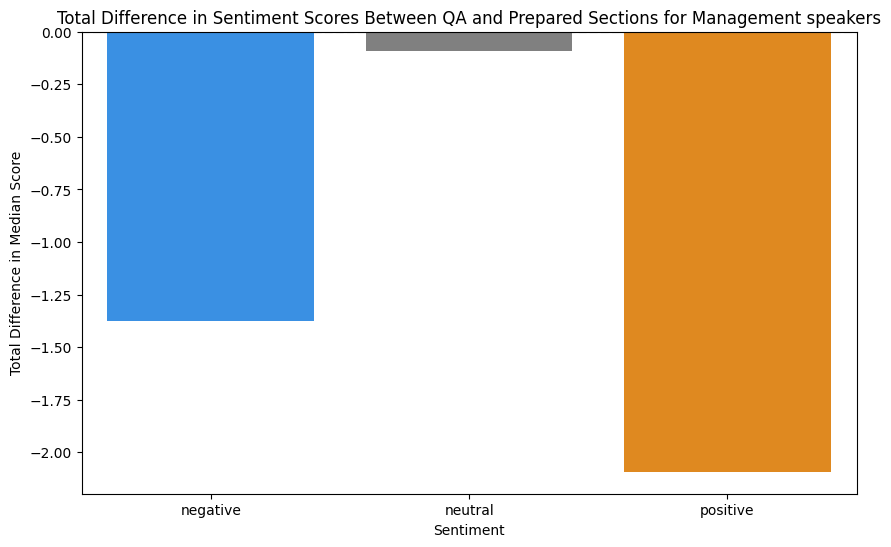

In [46]:
# Plot total sentiment differences across all quarters
total_diff_sentiment_stats = diff_sentiment_stats.groupby('main_sentiment')['diff'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=total_diff_sentiment_stats, x="main_sentiment", y="diff", palette=sentiment_palette)
plt.axhline(0, linestyle='--', color='gray')
plt.title("Total Difference in Sentiment Scores Between QA and Prepared Sections for Management speakers")
plt.xlabel("Sentiment")
plt.ylabel("Total Difference in Median Score")
plt.savefig("total_diff_sentiment_scores.png")
plt.show()

## Positive Sentiments

### Median positive sentiment over time

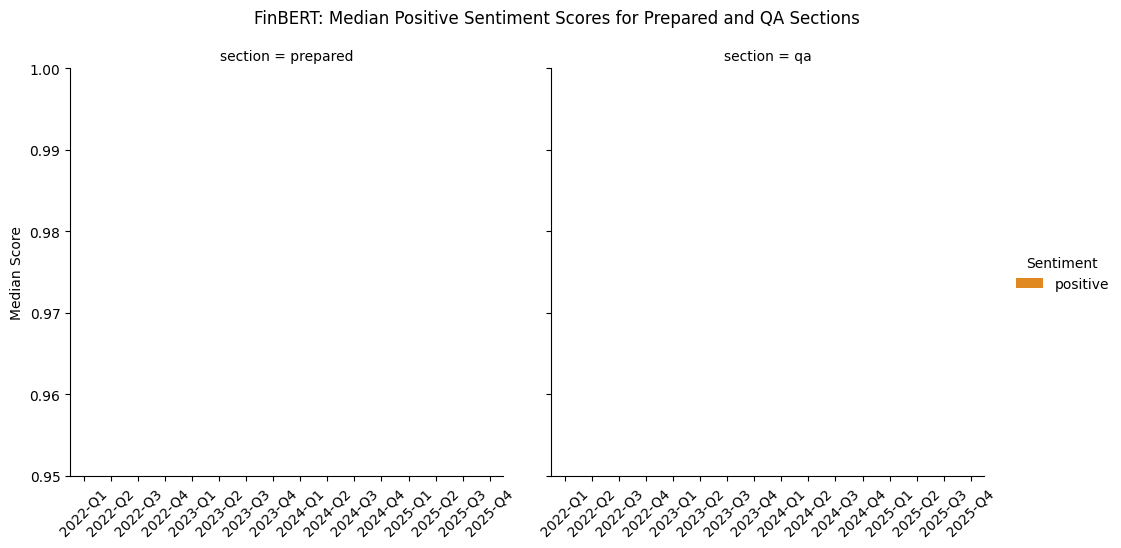

In [47]:
# Plot Positive Sentiment Scores for prepared and QA sections

positive_sentiments = ["positive"] 
positive_sentiments = sentiment_stats[sentiment_stats['main_sentiment'].isin(positive_sentiments)].copy()

g = sns.catplot(
    kind="bar",
    data=positive_sentiments,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_sentiment",
    palette=sentiment_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Set y limits for better visualization
g.set(ylim=(0.95, 1))
# Remove x title
g.set_xlabels("")
g.legend.set_title("Sentiment")
g.fig.suptitle("FinBERT: Median Positive Sentiment Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in positive sentiment over time

In [48]:
# Find max standard deviation for "Positive" from sentiment_std_max values
positive_sentiment_std_max = sentiment_std_max[sentiment_std_max.index.isin(['positive'])].max()
print("Value for error bars: ", positive_sentiment_std_max)


Value for error bars:  0.19259493892601787


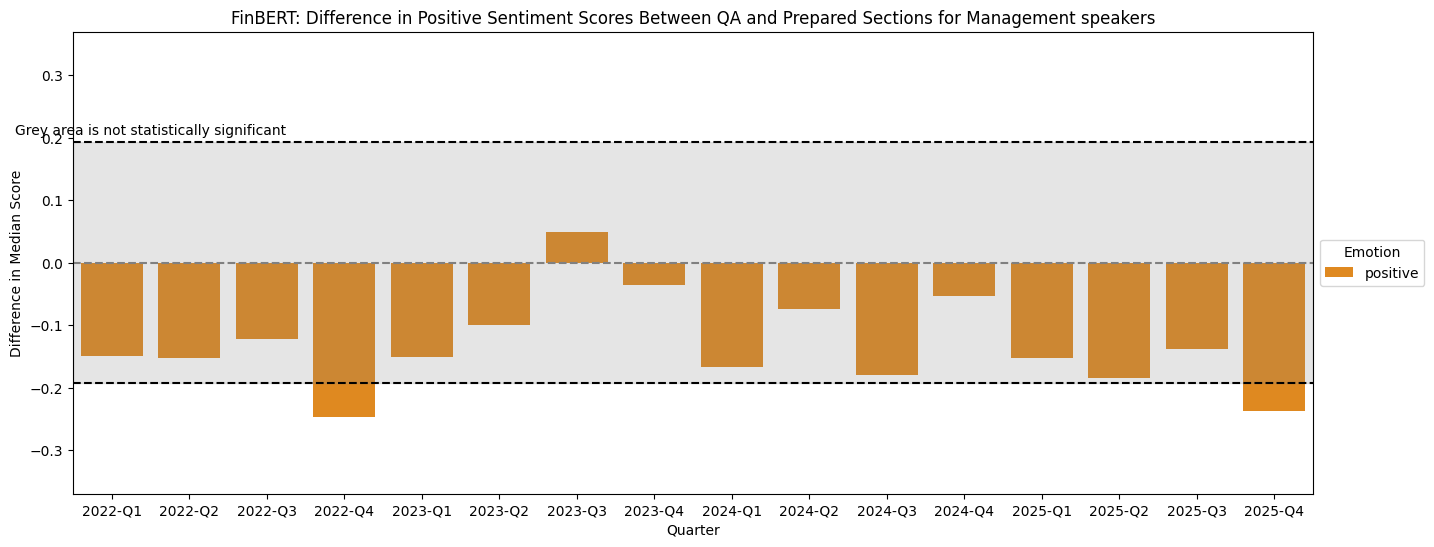

In [49]:
# Plot results as bar chart for "Positive" sentiment only
diff_positive_sentiment_stats = diff_sentiment_stats[diff_sentiment_stats['main_sentiment'].isin(['positive'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_positive_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)
# Positive median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_positive_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of positive sentiment standard deviation
plt.axhline(positive_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-positive_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -positive_sentiment_std_max,
    positive_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Positive Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive sentiment scores"
plt.text(
    x=0.5, 
   y=0.2, 
   s="Grey area is not statistically significant", 
    color='black', 
   ha='center', 
    va='bottom'
)
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("diff_positive_sentiment_scores.png")
plt.show()

There is virtually no difference in positive sentiment between the prepared presentation and the Q&A section. Nothing is statistically significant.

## Negative Sentiments

### Median negative sentiment over time

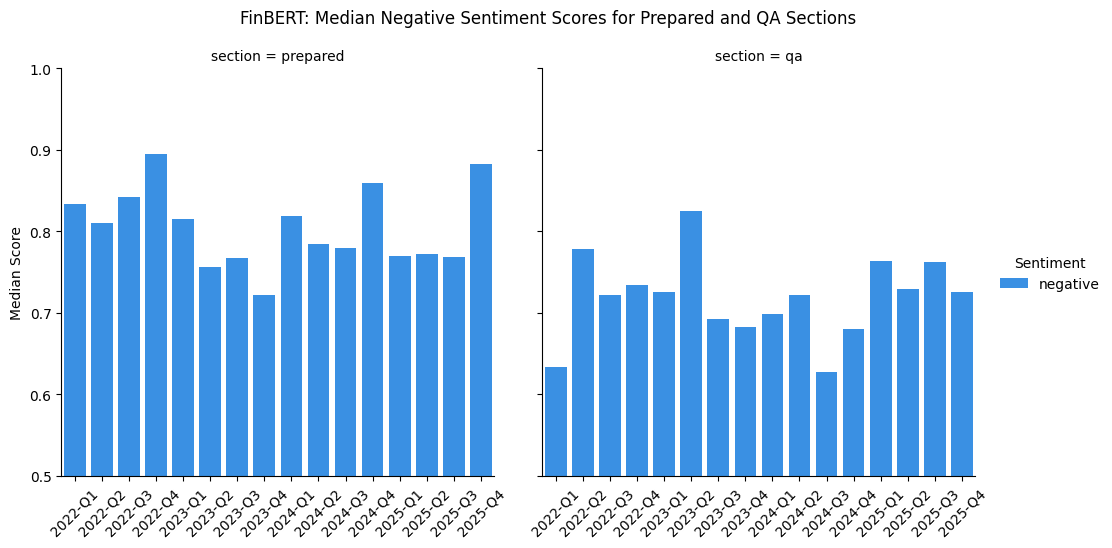

In [50]:
# Plot Negative Sentiment Scores for prepared and QA sections using "Negative" sentiment

negative_sentiment = ["negative"]
negative_sentiment = sentiment_stats[sentiment_stats['main_sentiment'].isin(negative_sentiment)].copy()

g = sns.catplot(
    kind="bar",
    data=negative_sentiment,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_sentiment",
    palette=sentiment_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Remove x title
g.set_xlabels("")
g.legend.set_title("Sentiment")
g.fig.suptitle("FinBERT: Median Negative Sentiment Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in negative sentiment over time

In [51]:
# Find max standard deviation for "Negative" from sentiment_std_max values
negative_sentiment_std_max = sentiment_std_max[sentiment_std_max.index.isin(['negative'])].max()
print("Value for error bars: ", negative_sentiment_std_max)

Value for error bars:  0.24817465880032338


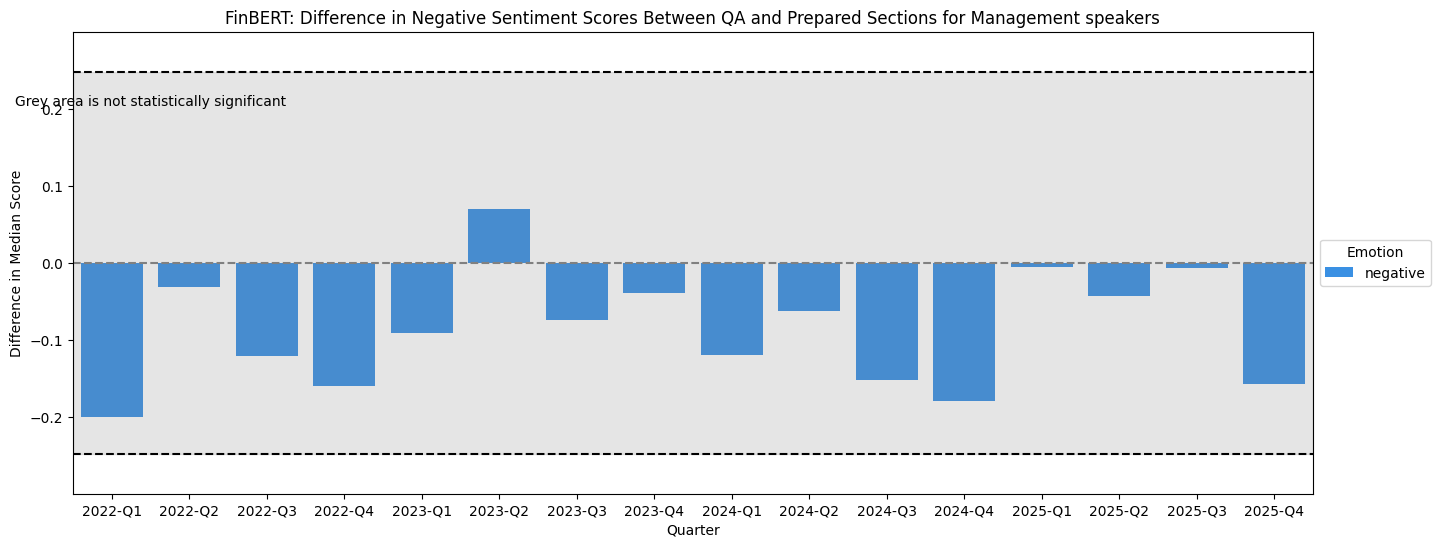

In [52]:
# Plot results as bar chart for "Negative" sentiment only
diff_negative_sentiment_stats = diff_sentiment_stats[diff_sentiment_stats['main_sentiment'].isin(['negative'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_negative_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)
# Negative median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_negative_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of negative sentiment standard deviation
plt.axhline(negative_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-negative_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -negative_sentiment_std_max,
    negative_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Negative Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive sentiment scores"
plt.text(
    x=0.5, 
   y=0.2, 
   s="Grey area is not statistically significant", 
    color='black', 
   ha='center', 
    va='bottom'
)
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("diff_negative_sentiment_scores.png")
plt.show()

Again, there are no statistically significant changes in sentiment between the prepared presentation and the Q&A section

## Neutral Sentiments

### Median neutral emotions over time

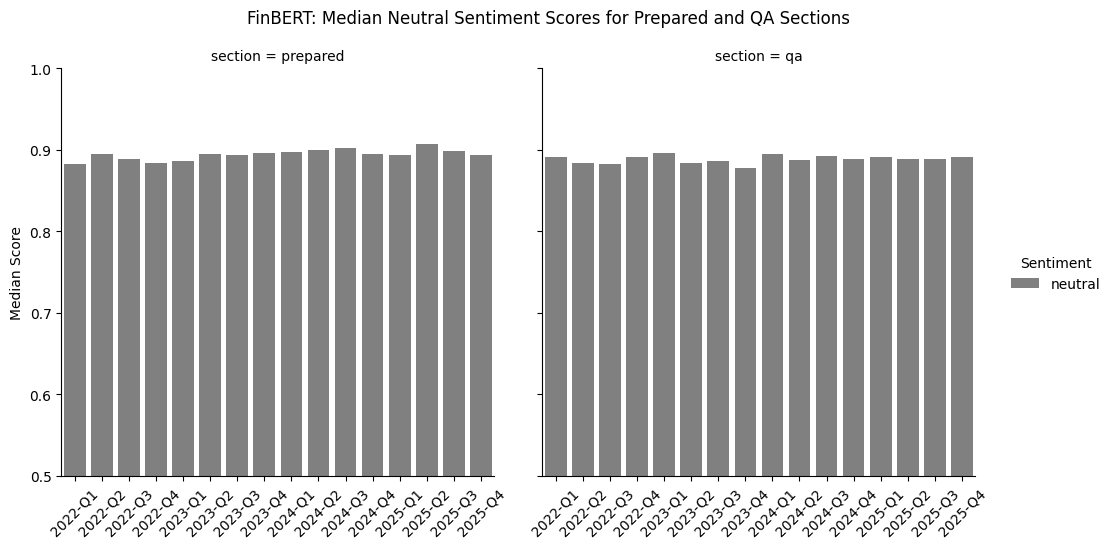

In [53]:
# Plot Neutral Sentiment Scores for prepared and QA sections using "Neutral" sentiment

neutral_sentiment = ["neutral"]
neutral_sentiment = sentiment_stats[sentiment_stats['main_sentiment'].isin(neutral_sentiment)].copy()

g = sns.catplot(
    kind="bar",
    data=neutral_sentiment,
    col="section",
    x="quarter",
    y="median_score",
    hue="main_sentiment",
    palette=sentiment_palette,
    errorbar=None,
)

# set y limits
g.set(ylim=(0.5, 1))
# Plot x labels at 45 degree
g.set_xticklabels(rotation=45)
# Set y label as Median Score
g.set_ylabels("Median Score")
# Remove x title
g.set_xlabels("")
g.legend.set_title("Sentiment")
g.fig.suptitle("FinBERT: Median Neutral Sentiment Scores for Prepared and QA Sections", y=1.05)
plt.show()

### Changes in neutral sentiment over time

In [54]:
# Find max standard deviation for "Neutral" from sentiment_std_max values
neutral_sentiment_std_max = sentiment_std_max[sentiment_std_max.index.isin(['neutral'])].max()
print("Value for error bars: ", neutral_sentiment_std_max)

Value for error bars:  0.24537990396933823


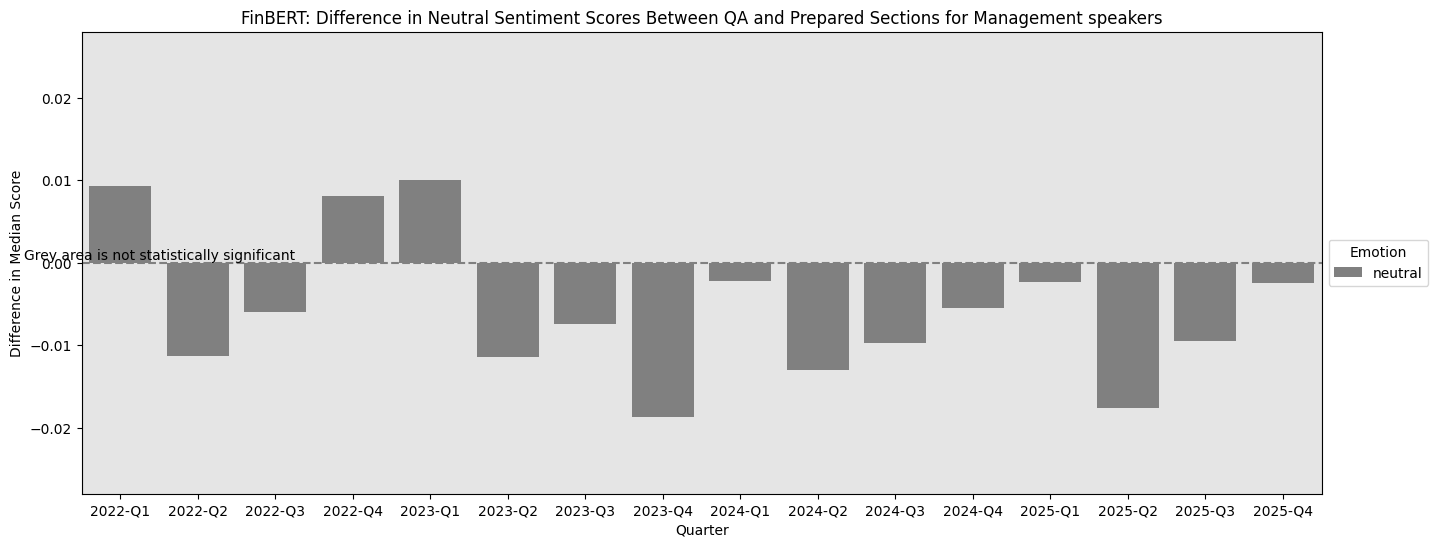

In [55]:
# Plot results as bar chart for "Neutral" sentiment only
diff_neutral_sentiment_stats = diff_sentiment_stats[diff_sentiment_stats['main_sentiment'].isin(['neutral'])]
plt.figure(figsize=(16, 6))
sns.barplot(data=diff_neutral_sentiment_stats, x="quarter", y="diff", hue="main_sentiment", palette=sentiment_palette)
# Neutral median scores are close to 1 in both sections, so the diff is tiny; zoom in to see it
diff_range = diff_neutral_sentiment_stats['diff'].abs().max() * 1.5
plt.ylim(-diff_range, diff_range)
plt.axhline(0, linestyle='--', color='gray')

# plot x-line at value of neutral sentiment standard deviation
plt.axhline(neutral_sentiment_std_max, linestyle='--', color='black')
plt.axhline(-neutral_sentiment_std_max, linestyle='--', color='black')
# infill area in grey across the whole x-axis
plt.axhspan(
    -neutral_sentiment_std_max,
    neutral_sentiment_std_max,
    color='grey',
    alpha=0.2
)

plt.title("FinBERT: Difference in Neutral Sentiment Scores Between QA and Prepared Sections for Management speakers")

# Add text onto plot "Grey area represents ±1 standard deviation of positive sentiment scores"
plt.text(
    x=0.5, 
   y=0, 
   s="Grey area is not statistically significant", 
    color='black', 
   ha='center', 
    va='bottom'
)
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Score")
plt.legend(title="Emotion", loc='center left', bbox_to_anchor=(1, 0.5))
# Save figure
plt.savefig("diff_neutral_sentiment_scores.png")
plt.show()

# Compare FinBERT and BERTemotion

### All sentences (Management & Analyst)

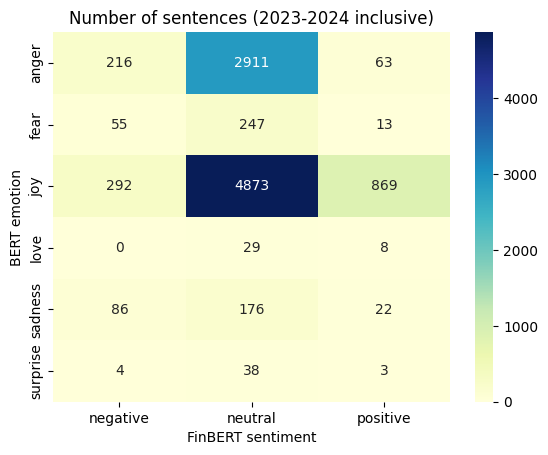

In [56]:
# Plot main_emotion and main_sentiment in data as a heatmap for comparison
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = pd.crosstab(data['main_emotion'], data['main_sentiment'])
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
# Label axes
plt.xlabel('FinBERT sentiment')
plt.ylabel('BERT emotion')
plt.title('Number of sentences (2023-2024 inclusive)')
plt.show()



NOTES:  


* Clearly the majority of the sentences are classified by BERT-emotion as "Joy" but they are split by FinBERT into mainly "Neutral" , rather than simply "Positive".  
* Interestingly FinBERT classifies some of the "Joy" sentences as "Negative" which would need further investigation.  
* It also indicates that the large number of those classified as "Anger" are also "Neutral" in a financial context
* This is repeated in a smaller sense for "Sadness"


### Management sentences only

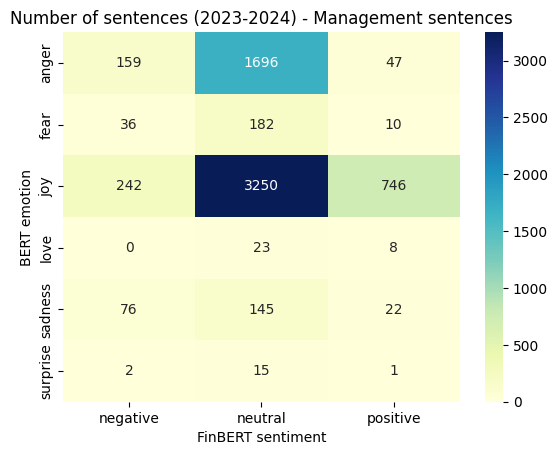

In [57]:
# Plot main_emotion and main_sentiment in data as a heatmap for comparison but only management sentences
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = pd.crosstab(data.loc[data['speaker_role'] == 'management', 'main_emotion'], 
                           data.loc[data['speaker_role'] == 'management', 'main_sentiment'])
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")
# Label axes
plt.xlabel('FinBERT sentiment')
plt.ylabel('BERT emotion')
plt.title('Number of sentences (2023-2024) - Management sentences')
plt.show()

This shows a very similar pattern to all the sentences in the data.  

* The one sentence classified as "Surprise" by BERTemotion was classified as "Neutral" by FinBERT

### Compare Model output on Q&A and Prepared sections

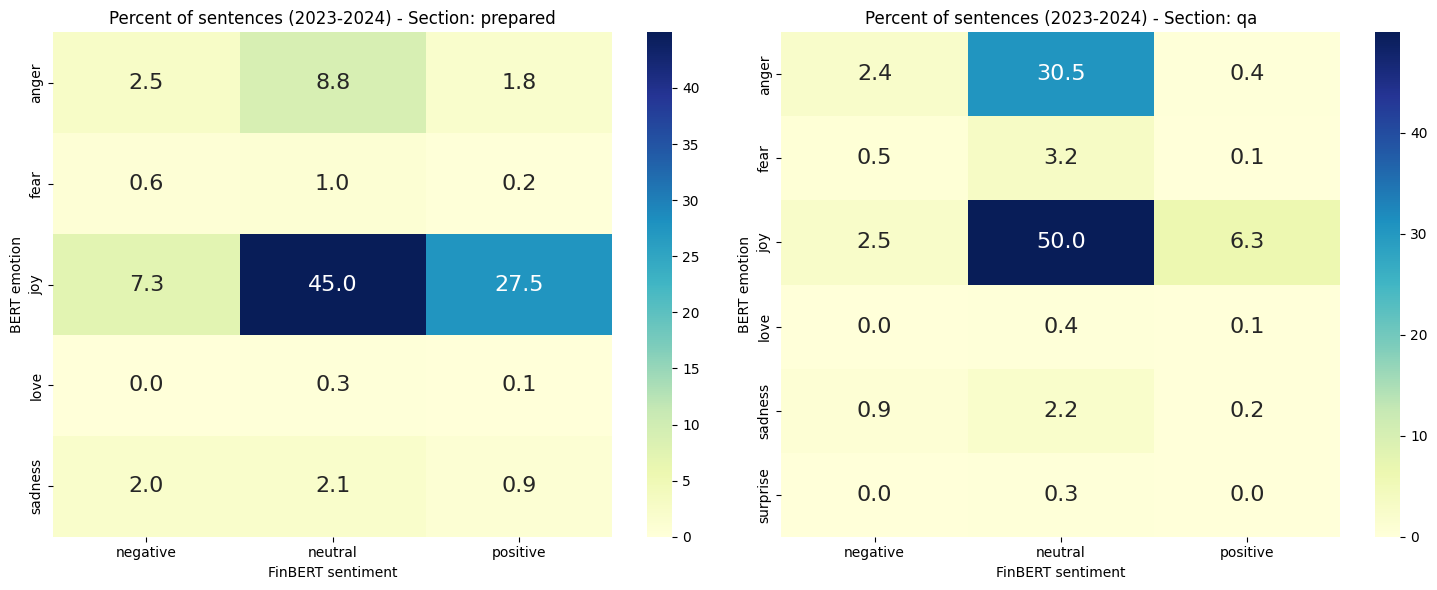

In [62]:
# Create two heatmaps side by side with speaker_role = management but split by section
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Display values as % of total number in large font
sections = data['section'].unique()
for i, section in enumerate(sections[:2]):  # Only take the first two sections for side by side comparison
    heatmap_data = pd.crosstab(
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_emotion'],
        data.loc[(data['speaker_role'] == 'management') & (data['section'] == section), 'main_sentiment']
    )
    heatmap_data = heatmap_data / heatmap_data.values.sum() * 100  # Convert to percentage
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], annot_kws={"size": 16})
    axes[i].set_xlabel('FinBERT sentiment')
    axes[i].set_ylabel('BERT emotion')
    axes[i].set_title(f'Percent of sentences (2023-2024) - Section: {section}')

plt.tight_layout()

# Save each subplot as its own image using its extent, plus the combined figure
for i, section in enumerate(sections[:2]):
    extent = axes[i].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(f'heatmap_management_section_{section}.png', bbox_inches=extent)
fig.savefig('heatmaps_management_sections.png')
plt.show()

FinBERT = positive and BERTemotion = "joy" is straightforward to understand, however FinBERT = neutral and BERTemotion = "anger" needs further investigation

## Investigate Q&A sentences where FinBERT = Neutral but BERTemotion = Anger

In [59]:
# Create dataframe of sentences where main_emotion = "anger" and main_sentiment = "Neutral" for management where section = qa
df_anger_neutral = data[(data['main_emotion'] == 'anger') & (data['main_sentiment'] == 'neutral') & (data['speaker_role'] == 'management') & (data['section'] == 'qa')]

df_anger_neutral['cleaned_text'].head(5)

101                                                   []
102                                                   []
106                      [want, run, bottomsup, process]
112                                                   []
113    [guess, would, direct, comment, one, two, ago,...
Name: cleaned_text, dtype: object

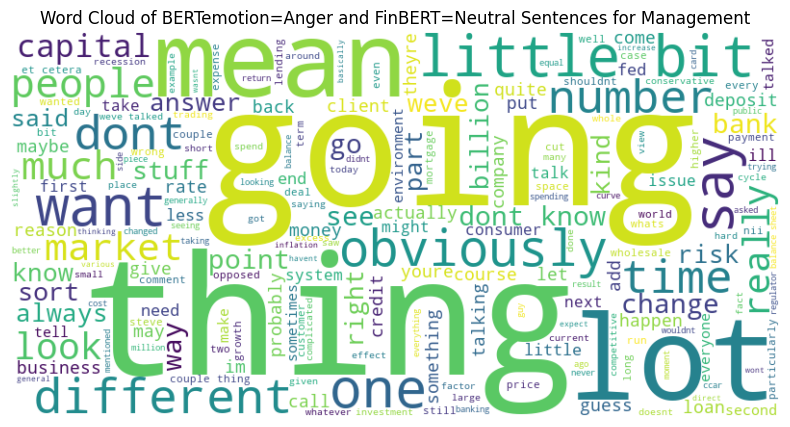

In [60]:
# Create a word cloud of sentences where main_emotion = "anger" and main_sentiment = "Neutral" for management
from wordcloud import WordCloud

# cleaned_text holds token lists, so flatten each row before joining
text = " ".join(word for tokens in df_anger_neutral['cleaned_text'] for word in tokens)
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(text)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of BERTemotion=Anger and FinBERT=Neutral Sentences for Management')
plt.axis('off')
# Save figure
plt.savefig('wordcloud_anger_neutral_management_qa.png')
plt.show()

# Final Scorecard
To demonstrate the comparison of the models

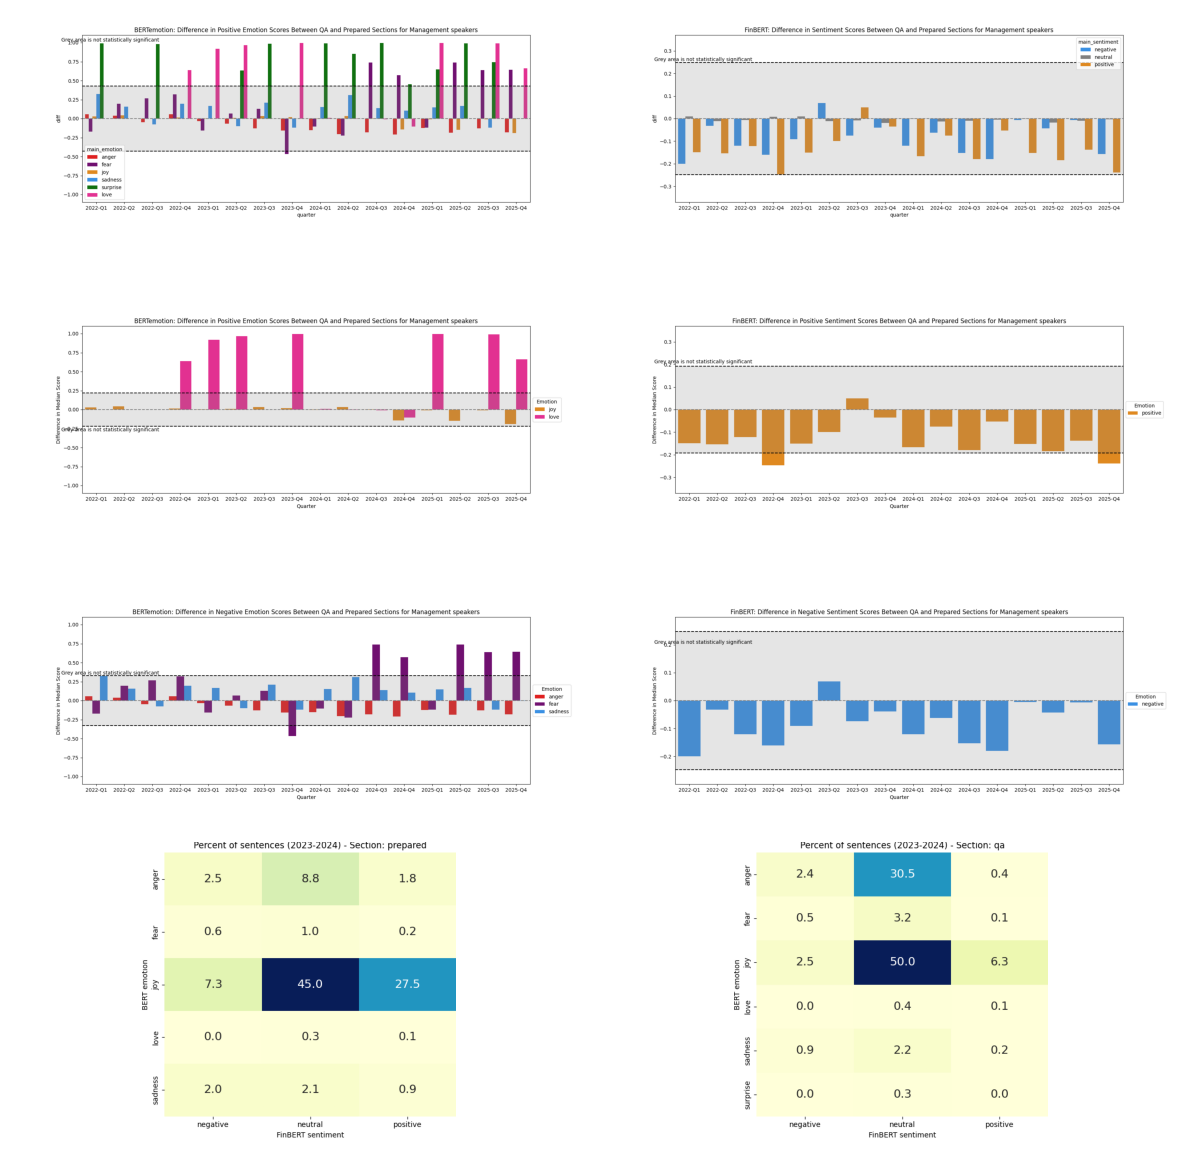

In [63]:
# Build scorecard of 3x2 subplots
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
metrics = met['metric_name'].unique()

# Plot [0,0] as the total revenues  
img_trq = plt.imread('difference_in_emotion_scores_management.png')
axes[0, 0].imshow(img_trq)
axes[0, 0].axis('off')


# Plot [0,1] as the net profit
img_np = plt.imread('difference_in_sentiment_scores_management.png')
axes[0, 1].imshow(img_np)
axes[0, 1].axis('off')


# Plot [1,0] as BERTemotion
img_tt = plt.imread('diff_positive_emotion_scores.png')
axes[1, 0].imshow(img_tt)
axes[1, 0].axis('off')


# Plot [1,1] as FinBERT
img_se = plt.imread('diff_positive_sentiment_scores.png')
axes[1, 1].imshow(img_se)
axes[1, 1].axis('off')

# Plot [2,0] as placeholder for future plot
img_placeholder = plt.imread('diff_negative_emotion_scores.png')
axes[2, 0].imshow(img_placeholder)
axes[2, 0].axis('off')

# Plot [2,1] as placeholder for future plot
img_placeholder2 = plt.imread('diff_negative_sentiment_scores.png')
axes[2, 1].imshow(img_placeholder2)
axes[2, 1].axis('off')

# Plot [3,0] as placeholder for future plot
img_placeholder3 = plt.imread('heatmap_management_section_prepared.png')
axes[3, 0].imshow(img_placeholder3)
axes[3, 0].axis('off')

# Plot [3,1] as placeholder for future plot
img_placeholder4 = plt.imread('heatmap_management_section_qa.png')
axes[3, 1].imshow(img_placeholder4)
axes[3, 1].axis('off')



plt.tight_layout()
# Save the scorecard figure
plt.savefig('scorecard_BERTemotion_vs_FinBERT.png')
plt.show()

# Add 3rd Model ????